# Japan Trade Intelligence — 03: Sector Analysis

**Input:** Japan's Sector import/export data
**Goal:** Analysis which sectors is growing

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load sector data
sectors_raw = pd.read_csv("../data/raw/japan_sectors_raw.csv",
                         encoding='latin-1',
                         index_col=False)

print(f"Shape: {sectors_raw.shape}")
print(f"\nColumns: {sectors_raw.columns.tolist()}")
print(f"Unique HS codes: {sectors_raw['cmdCode'].unique()}")
print(f"Unique years: {sorted(sectors_raw['refYear'].unique())}")
print(f"\nFlow types: {sectors_raw['flowDesc'].unique()}")
sectors_raw.head(3)

Shape: (120, 47)

Columns: ['typeCode', 'freqCode', 'refPeriodId', 'refYear', 'refMonth', 'period', 'reporterCode', 'reporterISO', 'reporterDesc', 'flowCode', 'flowDesc', 'partnerCode', 'partnerISO', 'partnerDesc', 'partner2Code', 'partner2ISO', 'partner2Desc', 'classificationCode', 'classificationSearchCode', 'isOriginalClassification', 'cmdCode', 'cmdDesc', 'aggrLevel', 'isLeaf', 'customsCode', 'customsDesc', 'mosCode', 'motCode', 'motDesc', 'qtyUnitCode', 'qtyUnitAbbr', 'qty', 'isQtyEstimated', 'altQtyUnitCode', 'altQtyUnitAbbr', 'altQty', 'isAltQtyEstimated', 'netWgt', 'isNetWgtEstimated', 'grossWgt', 'isGrossWgtEstimated', 'cifvalue', 'fobvalue', 'primaryValue', 'legacyEstimationFlag', 'isReported', 'isAggregate']
Unique HS codes: [27 29 72 84 85 87]
Unique years: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]

Flow types: <StringArray>
['Import', 'Export']
Length: 2, 

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,C,A,20140101,2014,52,2014,392,JPN,Japan,M,...,NaN,False,NaN,False,2.621061e+11,NaN,2.621061e+11,0,True,False
1,C,A,20140101,2014,52,2014,392,JPN,Japan,M,...,NaN,False,NaN,False,1.521086e+10,NaN,1.521086e+10,0,True,False
2,C,A,20140101,2014,52,2014,392,JPN,Japan,M,...,NaN,False,NaN,False,8.524468e+09,NaN,8.524468e+09,0,True,False


In [2]:
# Why these 5 columns:
# cmdCode = the HS sector code (27=Energy, 87=Auto, etc..)
# cmdDesc = human readable sector name for verification
# We keep both to map codes -> sector labels cleanly

cols = ['refYear', 'flowDesc', 'cmdCode', 'cmdDesc', 'primaryValue']
sectors = sectors_raw[cols].copy()

sectors = sectors.rename(columns={
    'refYear': 'year',
    'flowDesc': 'flow',
    'cmdCode': 'hs_code',
    'cmdDesc': 'hs_desc',
    'primaryValue': 'value_usd'
})

print("Cleaned shape:", sectors.shape)
print("\nHS codes and descriptions:")
print(sectors.groupby(['hs_code', 'hs_desc']).size().reset_index().
                      drop(columns=0).to_string(index=False))

Cleaned shape: (120, 5)

HS codes and descriptions:
 hs_code                                                                                                                                                                             hs_desc
      27                                                                                Mineral fuels, mineral oils and products of their distillation; bituminous substances; mineral waxes
      29                                                                                                                                                                   Organic chemicals
      72                                                                                                                                                                      Iron and steel
      84                                                                                                       Machinery and mechanical appliances, boilers, nuclear reactors; parts thereof
   

### Map HS codes to sector names

In [3]:
# Why create sector_name column:
# HS codes like 84, 85, 87 are meaningless to readers
# "Machinery", "Electronics", "Automotive" are instantly clear

sector_map = {
    27: 'Energy(Fuels)',
    29: 'Chemicals',
    72: 'Steel & Metals',
    84: 'Machinery',
    85: 'Electronics',
    87: 'Automotive'
}
sectors['sector'] = sectors['hs_code'].map(sector_map)
sectors['value_bn'] = sectors['value_usd'] / 1e9

print("Sectors Mapped:")
print(sectors['sector'].unique())
print(f"\nNull sectors: {sectors['sector'].isnull().sum()}")
print(f"\nShape: {sectors.shape}")
sectors.head(6)

Sectors Mapped:
<StringArray>
[ 'Energy(Fuels)',      'Chemicals', 'Steel & Metals',      'Machinery',
    'Electronics',     'Automotive']
Length: 6, dtype: str

Null sectors: 0

Shape: (120, 7)


,year,flow,hs_code,hs_desc,value_usd,sector,value_bn
0,2014,Import,27,"Mineral fuels, mineral oils and products of th...",2.621061e+11,Energy(Fuels),262.106100
1,2014,Import,29,Organic chemicals,1.521086e+10,Chemicals,15.210857
2,2014,Import,72,Iron and steel,8.524468e+09,Steel & Metals,8.524468
3,2014,Import,84,"Nuclear reactors, boilers, machinery and mecha...",6.504161e+10,Machinery,65.041607
4,2014,Import,85,Electrical machinery and equipment and parts t...,9.934624e+10,Electronics,99.346235
5,2014,Import,87,Vehicles; other than railway or tramway rollin...,2.156627e+10,Automotive,21.566267


### Export sector breakdown 2023

In [4]:
# Why focus on exports first:
# Japan's Export sector composition tells us WHERE
# Japan's competitive strength lies
# Import sectors tells us WHERE Japan is dependent
# Exports = strength. Imports = vulnerability.

exports_2023 = sectors[
    (sectors['year'] == 2023) & (sectors['flow'] == 'Export')
].copy()

exports_2023 = exports_2023.sort_values('value_bn', ascending=False)

print("Japan Export Sectors (2023)")
print(exports_2023[['sector', 'value_bn']].to_string(index=False))

total_exports = exports_2023['value_bn'].sum()
exports_2023['share_pct'] = (exports_2023['value_bn']/
                             total_exports * 100).round(1)

print(f"\nTotal (these 6 sectors): ${total_exports:.1f}bn")
print("\nWith shares:")
print(exports_2023[['sector', 'value_bn', 'share_pct']].to_string(index=False))

Japan Export Sectors (2023)
        sector   value_bn
    Automotive 157.301991
     Machinery 129.710721
   Electronics 101.888300
Steel & Metals  30.465519
     Chemicals  14.774153
 Energy(Fuels)  12.726473

Total (these 6 sectors): $446.9bn

With shares:
        sector   value_bn  share_pct
    Automotive 157.301991       35.2
     Machinery 129.710721       29.0
   Electronics 101.888300       22.8
Steel & Metals  30.465519        6.8
     Chemicals  14.774153        3.3
 Energy(Fuels)  12.726473        2.8


### Export Sector Bar Chart

In [5]:
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
    'axes.grid': True,
    'grid.color': '#E0E0E0',
    'grid.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False,
    'font.family': 'sans-serif',
    'axes.titlesize': 15,
    'axes.titleweight': '500',
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})

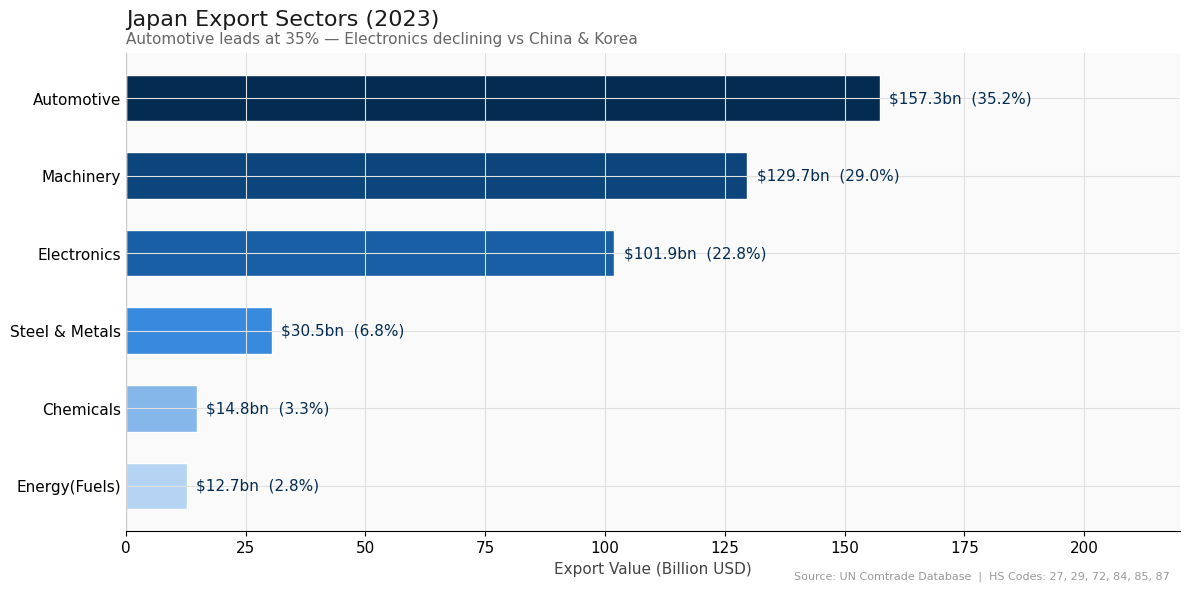

✓ Saved


In [6]:
colors = {
    'Automotive':     '#D32F2F',
    'Electronics':    '#1565C0',
    'Machinery':      '#2E7D32',
    'Chemicals':      '#F57F17',
    'Steel & Metals': '#6A1B9A',
    'Energy (Fuels)': '#37474F'
}

bar_colors = [colors.get(s, '#888') for s in exports_2023['sector']]


# WHY horizontal bar chart:
# Sector names are long — horizontal gives space to read them
# Sorted bars = instantly shows ranking without reading numbers
# Much more readable than vertical bars with rotated labels

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('white')

# Sort ascending so largest is at TOP
exports_sorted = exports_2023.sort_values('value_bn')

# WHY single color family with intensity variation:
# Different colors per bar = visual noise, no meaning
# Same color family, darker = larger = encodes magnitude
palette = ['#B5D4F4','#85B7EB','#378ADD','#185FA5','#0C447C','#042C53']

bars = ax.barh(exports_sorted['sector'],
               exports_sorted['value_bn'],
               color=palette,
               edgecolor='white',
               height=0.6)

# WHY annotate outside the bar:
# Inside labels get hidden when bar is short
# Outside labels are always readable
for bar, val, pct in zip(bars,
                          exports_sorted['value_bn'],
                          exports_sorted['share_pct']):
    ax.text(bar.get_width() + 2,
            bar.get_y() + bar.get_height()/2,
            f'${val:.1f}bn  ({pct}%)',
            va='center', fontsize=11,
            color='#042C53', fontweight='500')

# Title + subtitle — two-level typography
ax.set_title('Japan Export Sectors (2023)',
             fontsize=16, fontweight='500',
             pad=20, loc='left', color='#1a1a1a')

ax.text(0, 1.02,
        'Automotive leads at 35% — Electronics declining vs China & Korea',
        transform=ax.transAxes,
        fontsize=11, color='#666666')

ax.set_xlabel('Export Value (Billion USD)', fontsize=11, color='#444')
ax.set_xlim(0, 220)
ax.axvline(x=0, color='#CCCCCC', linewidth=1)
ax.tick_params(axis='y', length=0)

ax.text(0.99, -0.1,
        'Source: UN Comtrade Database  |  HS Codes: 27, 29, 72, 84, 85, 87',
        transform=ax.transAxes, fontsize=8,
        color='#999999', ha='right')

plt.tight_layout()
plt.savefig("../reports/export_sectors_2023_pro.png",
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Saved")


### Import sector breakdown 2023

In [7]:
# Why Imports matter here:
# Energy (HS 27) imports reveal Japan's Energy vulnerability
# Comparing Export vs Import in same sectors show
# Whether Japan is net buyer or seller in each category

imports_2023 = sectors[
    (sectors['year'] == 2023) & (sectors['flow'] == 'Import')
]

imports_2023 = imports_2023.sort_values('value_bn', ascending=False)
total_imports = imports_2023['value_bn'].sum()

imports_2023['share_pct'] = (imports_2023['value_bn']/
                             total_imports * 100).round(1)

print("Japan Import Sectors (2023)")
print(imports_2023[['sector', 'value_bn', 'share_pct']].to_string(index=False))

Japan Import Sectors (2023)
        sector   value_bn  share_pct
 Energy(Fuels) 194.666525       45.5
   Electronics 115.086540       26.9
     Machinery  69.312563       16.2
    Automotive  24.895148        5.8
     Chemicals  15.347806        3.6
Steel & Metals   8.321485        1.9


### Export vs Import comparison by sector

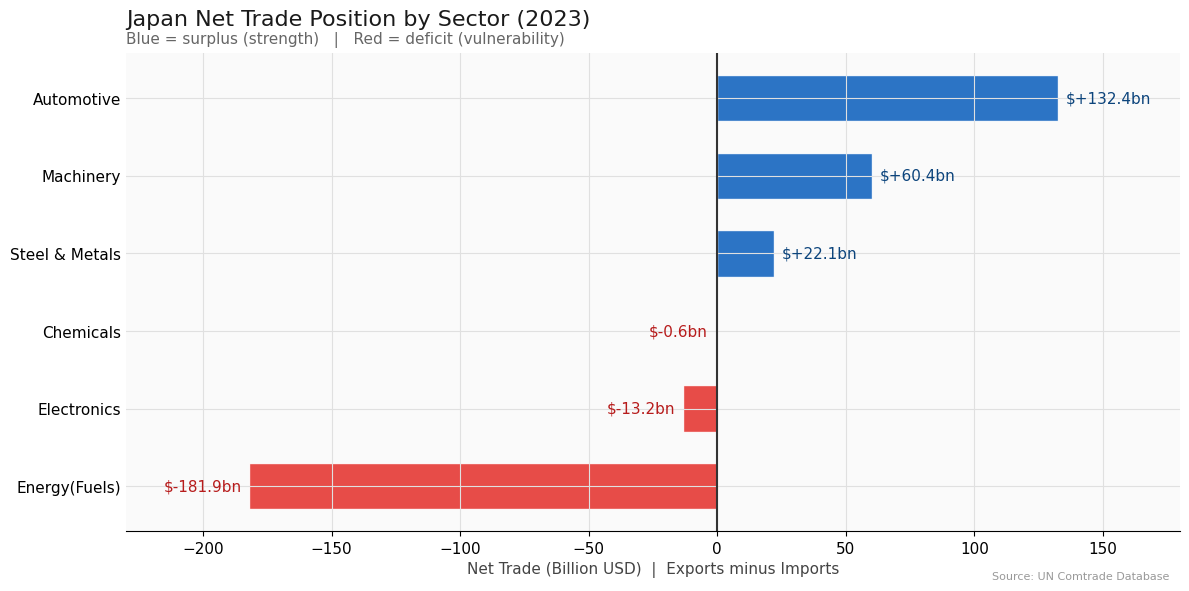

✓ Saved


In [8]:
# WHY diverging bar chart:
# Positive = surplus (Japan exports more)
# Negative = deficit (Japan imports more)
# Diverging from zero = instantly shows direction
# This is how economists show net trade position

exp_2023 = sectors[
    (sectors['flow'] == 'Export') &
    (sectors['year'] == 2023)
][['sector','value_bn']].rename(columns={'value_bn':'exports_bn'})

imp_2023 = sectors[
    (sectors['flow'] == 'Import') &
    (sectors['year'] == 2023)
][['sector','value_bn']].rename(columns={'value_bn':'imports_bn'})

comparison = exp_2023.merge(imp_2023, on='sector')
comparison['net_bn'] = comparison['exports_bn'] - comparison['imports_bn']
comparison = comparison.sort_values('net_bn')

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('white')

bar_colors = ['#E53935' if v < 0 else '#1565C0'
              for v in comparison['net_bn']]

bars = ax.barh(comparison['sector'],
               comparison['net_bn'],
               color=bar_colors,
               edgecolor='white',
               height=0.6,
               alpha=0.9)

for bar, val in zip(bars, comparison['net_bn']):
    x_pos = bar.get_width()
    ha = 'left' if val >= 0 else 'right'
    offset = 3 if val >= 0 else -3
    color = '#0C447C' if val >= 0 else '#B71C1C'
    ax.text(x_pos + offset,
            bar.get_y() + bar.get_height()/2,
            f'${val:+.1f}bn',
            va='center', fontsize=11,
            color=color, fontweight='500', ha=ha)

ax.axvline(x=0, color='#333333', linewidth=1.5)
ax.set_title('Japan Net Trade Position by Sector (2023)',
             fontsize=16, fontweight='500',
             pad=20, loc='left', color='#1a1a1a')
ax.text(0, 1.02,
        'Blue = surplus (strength)   |   Red = deficit (vulnerability)',
        transform=ax.transAxes, fontsize=11, color='#666666')
ax.set_xlabel('Net Trade (Billion USD)  |  Exports minus Imports',
              fontsize=11, color='#444')
ax.tick_params(axis='y', length=0)
ax.set_xlim(-230, 180)
ax.spines[['top','right','left']].set_visible(False)
ax.text(0.99, -0.1, 'Source: UN Comtrade Database',
        transform=ax.transAxes, fontsize=8,
        color='#999999', ha='right')

plt.tight_layout()
plt.savefig("../reports/sector_net_position_pro.png",
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Saved")

## Key Finding 8 — Japan's Sector Trade Position (2023)

Japan's trade strength is built entirely on three manufacturing sectors:
Automotive (+$132bn), Machinery (+$60bn), and Steel & Metals (+$22bn).

Two major vulnerabilities emerge:

**Energy (-$182bn):** Japan imports $195bn in mineral fuels while 
exporting only $13bn. This single sector creates Japan's entire 
structural trade deficit. Without energy imports, Japan would run 
a $200bn+ annual surplus. Every yen that weakens costs Japan more 
on this $195bn energy bill.

**Electronics (-$13bn):** Japan was once the world leader in 
consumer electronics. Today Japan is a net importer — buying $115bn 
from China and Korea while selling $102bn. This represents a 
structural decline in a historic Japanese strength, driven by 
competition from Samsung, LG, and Chinese manufacturers.

METI implication: Japan's economic security requires both an energy 
transition (reduce the -$182bn drag) and a semiconductor/electronics 
revival strategy (reverse the electronics deficit).

## Sector Trends Over Time

Not Just what sectors look like in 2023 - but how have they CHANGED from 2014 to 2023?
Is Automotive growing or declining? Is Electronics recovering or falling further? Is Energy 
dependency getting worse?

### Sector trend pivot

In [9]:
# Why pivot by year and sector:
# We want to see each sector's value across all 10 years
# Pivot gives us as rows, sectors as columns

exports_trend = sectors[sectors['flow'] == 'Export'].copy()
imports_trend = sectors[sectors['flow'] == 'Import'].copy()

# pivot_table handles any duplicate entries safely

exp_pivot = exports_trend.pivot_table(
    index='year',
    columns='sector',
    values='value_bn',
    aggfunc='sum'
)

imp_pivot = imports_trend.pivot_table(
    index='year',
    columns='sector',
    values='value_bn',
    aggfunc='sum'
)

print("Export trend pivot:")
print(exp_pivot.round(1).to_string())

Export trend pivot:
sector  Automotive  Chemicals  Electronics  Energy(Fuels)  Machinery  Steel & Metals
year                                                                                
2014         142.5       23.4        104.1           15.8      132.4            33.4
2015         134.0       17.9         95.6           11.4      117.6            27.5
2016         141.8       15.9         98.2            9.4      124.0            24.5
2017         146.2       17.9        105.6           11.4      138.4            28.0
2018         154.1       18.9        109.4           13.4      147.9            29.9
2019         148.8       17.8        103.0           14.0      137.0            26.1
2020         122.5       14.9        102.6            7.6      121.7            22.8
2021         137.8       18.3        118.9           10.2      147.3            34.8
2022         135.7       17.1        113.3           18.2      141.8            34.9
2023         157.3       14.8        101.9   

### Export sector trends chart:

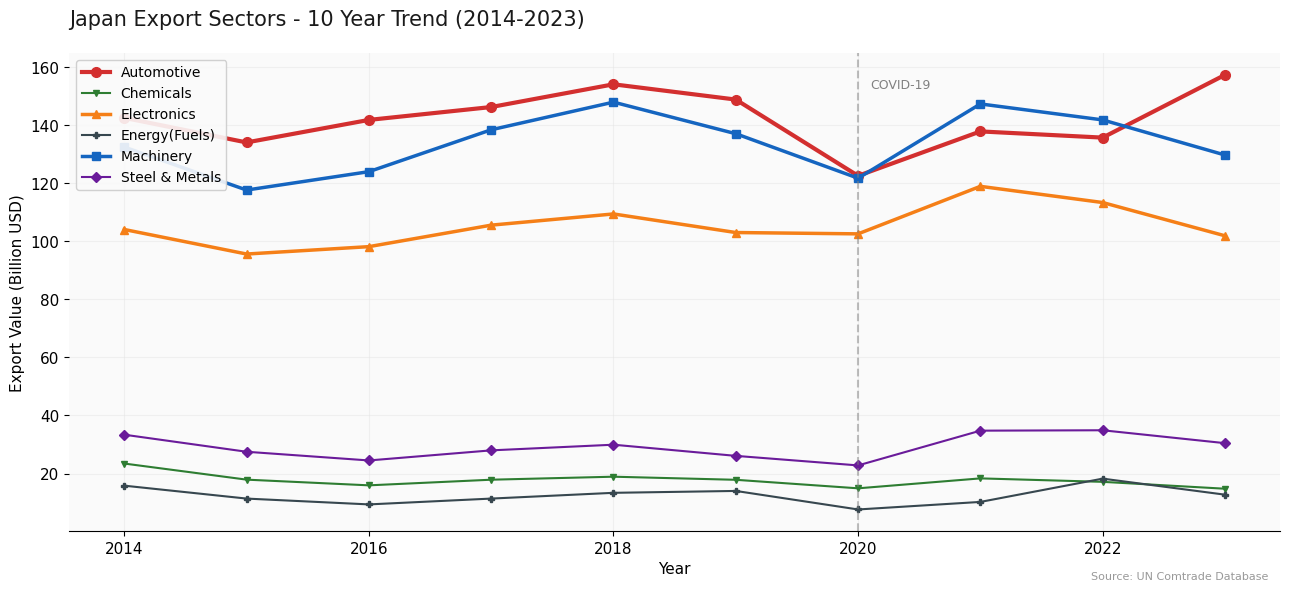

✓ Saved


In [10]:
# Why multi-line chart for trends:
# bar chart shows one point in titme
# line chart shows movement over time
# We want to see: is each sector growing or shrinking?
# the slope of each line tells the competitive story

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('white')


sector_styles = {
    'Automotive':    {'color':'#D32F2F','lw':3,  'marker':'o','ms':7},
    'Machinery':     {'color':'#1565C0','lw':2.5,'marker':'s','ms':6},
    'Electronics':   {'color':'#F57F17','lw':2.5,'marker':'^','ms':6},
    'Steel & Metals':{'color':'#6A1B9A','lw':1.5,'marker':'D','ms':5},
    'Chemicals':     {'color':'#2E7D32','lw':1.5,'marker':'v','ms':5},
    'Energy(Fuels)': {'color':'#37474F','lw':1.5,'marker':'P','ms':5},
}


for sector in exp_pivot.columns:
    if sector in sector_styles:
        s = sector_styles[sector]
        ax.plot(exp_pivot.index, 
                exp_pivot[sector],
                label=sector,
                color=s['color'],
                linewidth=s['lw'],
                marker=s['marker'],
                markersize=s['ms'])
        

# Why annotate COVID:
# 2020 drop is visible in every sector
# Without annotation, readers wonder "why the dip"
# With annotation, the chart tells its own story
ax.axvline(x=2020, color='gray', linestyle='--', alpha=0.5)
ax.text(2020.1, exp_pivot.max().max()*0.97,
        'COVID-19', fontsize=9, color='gray')

ax.set_title('Japan Export Sectors - 10 Year Trend (2014-2023)',
             fontsize=15, fontweight='500', pad=20,
             loc='left', color='#1a1a1a')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Export Value (Billion USD)', fontsize=11)
ax.legend(fontsize=10, loc='upper left',
          framealpha=0.9, edgecolor='#CCCCCC')
ax.grid(True, alpha=0.4, color='#E0E0E0')
ax.spines[['top','right','left']].set_visible(False)

ax.text(0.99, -0.1, 'Source: UN Comtrade Database',
        transform=ax.transAxes, fontsize=8,
        color='#999', ha='right')

plt.tight_layout()
plt.savefig("../reports/export_sector_trends.png",
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Saved")

### Import sector trend chart

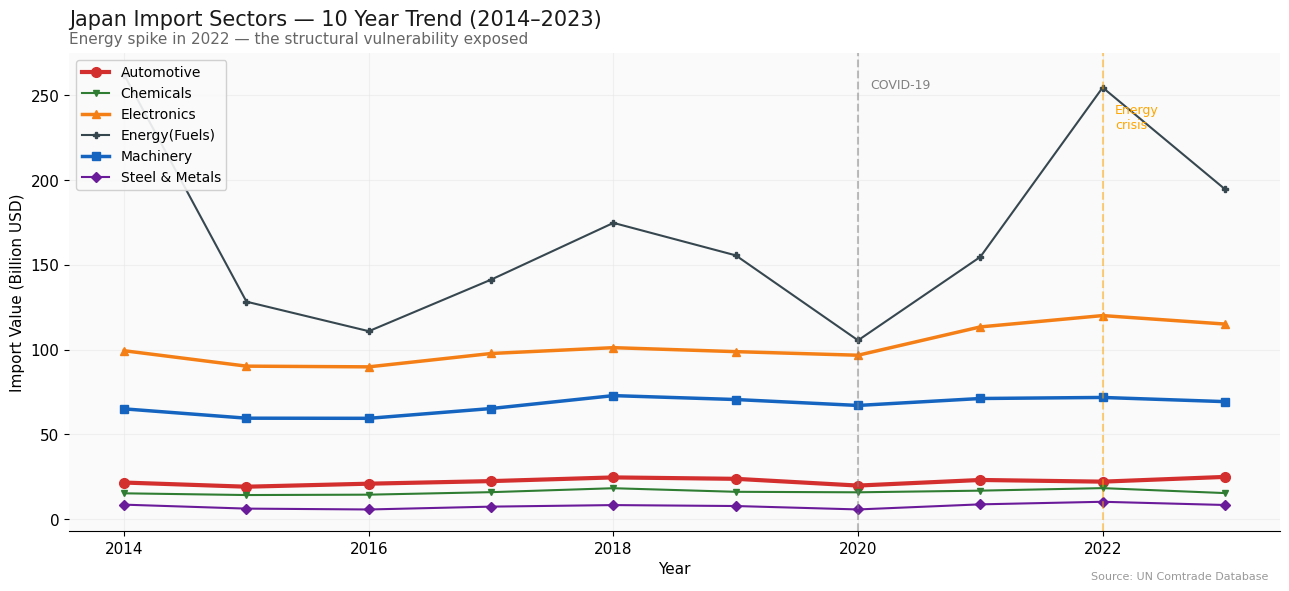

✓ Saved


In [11]:
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('white')

for sector in imp_pivot.columns:
    if sector in sector_styles:
        s = sector_styles[sector]
        ax.plot(imp_pivot.index,
                imp_pivot[sector],
                label=sector,
                color=s['color'],
                linewidth=s['lw'],
                marker=s['marker'],
                markersize=s['ms'])

ax.axvline(x=2020, color='gray', linestyle='--', alpha=0.5)
ax.text(2020.1, imp_pivot.max().max()*0.97,
        'COVID-19', fontsize=9, color='gray')

ax.axvline(x=2022, color='orange', linestyle='--', alpha=0.5)
ax.text(2022.1, imp_pivot.max().max()*0.88,
        'Energy\ncrisis', fontsize=9, color='orange')

ax.set_title('Japan Import Sectors — 10 Year Trend (2014–2023)',
             fontsize=15, fontweight='500', pad=20,
             loc='left', color='#1a1a1a')
ax.text(0, 1.02,
        'Energy spike in 2022 — the structural vulnerability exposed',
        transform=ax.transAxes, fontsize=11, color='#666')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Import Value (Billion USD)', fontsize=11)
ax.legend(fontsize=10, loc='upper left',
          framealpha=0.9, edgecolor='#CCCCCC')
ax.grid(True, alpha=0.4, color='#E0E0E0')
ax.spines[['top','right','left']].set_visible(False)

ax.text(0.99, -0.1, 'Source: UN Comtrade Database',
        transform=ax.transAxes, fontsize=8,
        color='#999', ha='right')

plt.tight_layout()
plt.savefig("../reports/import_sector_trends.png",
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Saved")

### Growth index per sector (2014 = 100):

In [12]:
# Why growth index for sectors:
# Automotive starts at $130bn. Electronics starts at $90bn.
# On absolute chart, Automotive line always sits higher.
# Growth index normalizes all to 100 in 2014 -
# now we compare GROWTH RATE not absolute size.
# The sector growing fastest = highest line by 2023.

exp_growth = exp_pivot.copy()
for sector in exp_growth.columns:
    base = exp_growth.loc[2014, sector]
    exp_growth[sector] = (exp_growth[sector] / base * 100).round(1)


print("Export Sector Growth Index (2014 = 100):")
print(exp_growth.to_string())

Export Sector Growth Index (2014 = 100):
sector  Automotive  Chemicals  Electronics  Energy(Fuels)  Machinery  Steel & Metals
year                                                                                
2014         100.0      100.0        100.0          100.0      100.0           100.0
2015          94.1       76.4         91.9           71.9       88.8            82.4
2016          99.5       68.0         94.3           59.2       93.6            73.4
2017         102.6       76.3        101.4           71.9      104.5            83.8
2018         108.1       80.7        105.1           84.4      111.7            89.7
2019         104.4       76.1         99.0           88.5      103.5            78.2
2020          86.0       63.6         98.6           48.2       91.9            68.3
2021          96.7       78.2        114.3           64.6      111.2           104.2
2022          95.2       73.1        108.9          115.3      107.1           104.6
2023         110.4      

### Growth Index chart

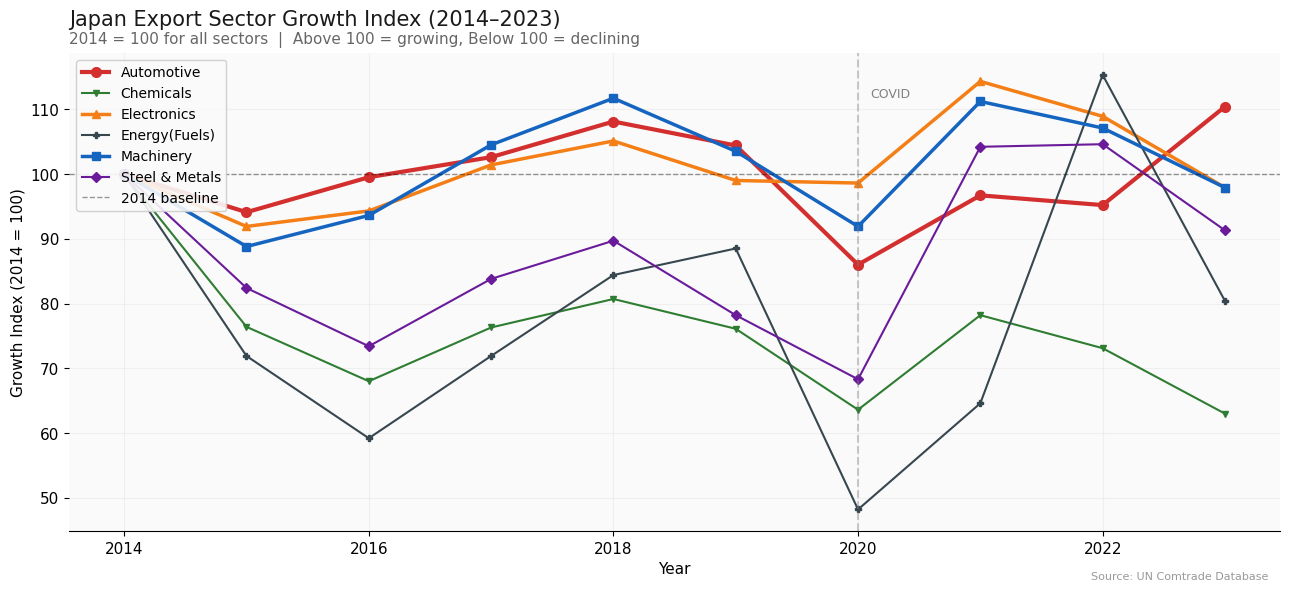

✓ Saved


In [13]:
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('white')

for sector in exp_growth.columns:
    if sector in sector_styles:
        s = sector_styles[sector]
        ax.plot(exp_growth.index,
                exp_growth[sector],
                label=sector,
                color=s['color'],
                linewidth=s['lw'],
                marker=s['marker'],
                markersize=s['ms'])

# WHY baseline at 100:
# Above 100 = sector is LARGER than 2014 = growing
# Below 100 = sector is SMALLER than 2014 = declining
# The 100 line is the single most important reference
ax.axhline(y=100, color='black', linewidth=1,
           linestyle='--', alpha=0.4, label='2014 baseline')

ax.axvline(x=2020, color='gray', linestyle='--', alpha=0.4)
ax.text(2020.1, exp_growth.max().max()*0.97,
        'COVID', fontsize=9, color='gray')

ax.set_title('Japan Export Sector Growth Index (2014–2023)',
             fontsize=15, fontweight='500', pad=20,
             loc='left', color='#1a1a1a')
ax.text(0, 1.02,
        '2014 = 100 for all sectors  |  Above 100 = growing, Below 100 = declining',
        transform=ax.transAxes, fontsize=11, color='#666')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Growth Index (2014 = 100)', fontsize=11)
ax.legend(fontsize=10, loc='upper left',
          framealpha=0.9, edgecolor='#CCCCCC')
ax.grid(True, alpha=0.4, color='#E0E0E0')
ax.spines[['top','right','left']].set_visible(False)

ax.text(0.99, -0.1, 'Source: UN Comtrade Database',
        transform=ax.transAxes, fontsize=8,
        color='#999', ha='right')

plt.tight_layout()
plt.savefig("../reports/sector_growth_index.png",
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Saved")

## Key Finding 9 — Sector Growth Trends (2014–2023)

#### Finding 1 - Sector grew fastest since 2014:
Only Automotive is growing By 2023, only one sector is larger that it was in 2014.
Toyota, Honda, Nissan are carrying Japan's entire export growth. Every other sector
has declined is USD terms. This is dangerous concentration

#### Finding 2 - Electronics below 2014:
Japan exports LESS electronics in 2023 than it did in 2014.Notice 2021 spike to 114.3 - that was the global semiconductor shortage when Japan's chip suppliers temporarily boomed. By 2023 it reversed to 97.9. The structural decline countinues.

#### Finding 3 - Machinery quietly declining:
Machinery was Japan's 2nd largest export sector but is also below basline. Industrial machinery demand shifted toward China-made alternatives.

#### Finding 4 - Chemicals collapesd 37%:
The biggest surpise. Japan's chemical exports fell from $23.4bn to $14.8bn -- a 37% drop over 10 years. Chinese chemical industry expansion directly displaced Japanese chemical exports.

#### Finding 5 - The 2021 Electronic spike:
Watch 2021 carefully: Electronics jumped to 114. That's the gloabl chip shortage - the world ran out of semiconductors and paid premium prices for Japanese components. It was temporary. By 2023 back below 2014.

#### The METI conclusion:
Japan's export base is dangerously concentrated in one sector. If Automotive declines - which is a real risk as EVs displace Japanese hybrid/ICE expertise - Japan loses its only growing export engine. This is the core competitiveness challange METI is trying to solve.